In [21]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
class LensDataset(Dataset):
    CLASS_NAMES = ['no', 'sphere', 'vort']

    def __init__(self, root_dir, img_size=150, augment=False):
        self.samples  = []
        self.img_size = img_size
        self.augment  = augment

        for label, cls in enumerate(self.CLASS_NAMES):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                raise FileNotFoundError(f"Expected class folder: {cls_path}")
            for fname in os.listdir(cls_path):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(cls_path, fname), label))

        print(f"Loaded {len(self.samples)} samples from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img[0]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self._load_image(path)

        img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        img_t = F.interpolate(img_t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False)
        img_t = img_t.squeeze(0)

        if self.augment:
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-1])
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-2])
            k = random.randint(0, 3)
            img_t = torch.rot90(img_t, k=k, dims=[-2, -1])

        return img_t, label

In [23]:
from torch.utils.data import random_split, Subset

IMG_SIZE   = 150
BATCH_SIZE = 32

TRAIN_DIR = "/kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train"
VAL_DIR   = "/kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/val"

# 90:10 split of the train folder
full_train = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
n_total    = len(full_train)
n_train    = int(0.9 * n_total)
n_test     = n_total - n_train

train_idx, test_idx = torch.utils.data.random_split(
    range(n_total), [n_train, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Augment only the training portion
train_dataset = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
train_dataset = Subset(train_dataset, train_idx.indices)

test_dataset  = Subset(full_train, test_idx.indices)

# Provided val folder (for final reporting)
val_dataset   = LensDataset(VAL_DIR, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Internal test (10%): {len(test_dataset)} | Val folder: {len(val_dataset)}")

Loaded 30000 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train
Loaded 30000 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train
Loaded 7500 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/val
Train: 27000 | Internal test (10%): 3000 | Val folder: 7500


In [24]:
class PolarTransform(nn.Module):
    def __init__(self, out_size=150):
        super().__init__()
        self.out_size = out_size

        self._build_grid(out_size)

    def _build_grid(self, S):

        r_vals   = torch.linspace(0, 1,    S)
        phi_vals = torch.linspace(-torch.pi, torch.pi, S)

        r_grid, phi_grid = torch.meshgrid(r_vals, phi_vals, indexing='ij')

        x = r_grid * torch.cos(phi_grid)
        y = r_grid * torch.sin(phi_grid)

        grid = torch.stack([x, y], dim=-1).unsqueeze(0)
        self.register_buffer('grid', grid)

    def forward(self, x):
        B = x.size(0)
        grid = self.grid.expand(B, -1, -1, -1)
        polar = F.grid_sample(x, grid,
                              mode='bilinear',
                              padding_mode='zeros',
                              align_corners=True)
        return polar

In [25]:
class LensWarp(nn.Module):
    """Forward-lens and de-lens."""
    def _grid(self, H, W, device):
        ys = torch.linspace(-1, 1, H, device=device)
        xs = torch.linspace(-1, 1, W, device=device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        return torch.stack([grid_x, grid_y], dim=-1)

    def forward(self, source, alpha):
        B, C, H, W = source.shape
        identity = self._grid(H, W, source.device).unsqueeze(0).expand(B, -1, -1, -1)
        alpha_perm = alpha.permute(0, 2, 3, 1)
        sample_grid = (identity - alpha_perm).clamp(-1, 1)
        return F.grid_sample(source, sample_grid,
                             mode='bilinear', padding_mode='border', align_corners=True)

    def delens(self, image, alpha):
        B, C, H, W = image.shape
        identity = self._grid(H, W, image.device).unsqueeze(0).expand(B, -1, -1, -1)
        alpha_perm = alpha.permute(0, 2, 3, 1)
        sample_grid = (identity + alpha_perm).clamp(-1, 1)
        return F.grid_sample(image, sample_grid,
                             mode='bilinear', padding_mode='border', align_corners=True)

class SISPrior(nn.Module):
    def __init__(self, in_channels, img_size=150):
        super().__init__()
        self.theta_E_head = nn.Sequential(
            nn.Linear(in_channels, 64), nn.ReLU(inplace=True),
            nn.Linear(64, 1), nn.Softplus())
        xs = torch.linspace(-1, 1, img_size)
        ys = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        r = torch.sqrt(grid_x**2 + grid_y**2 + 1e-6)
        self.register_buffer('r', r.unsqueeze(0).unsqueeze(0))
    def forward(self, feat):
        if feat.dim() == 4: feat = feat.mean(dim=[2, 3])
        theta_E = self.theta_E_head(feat)
        psi_sis = theta_E.unsqueeze(-1).unsqueeze(-1) * self.r
        return psi_sis, theta_E.squeeze(1)

class PotentialHead(nn.Module):
    """Central-difference gradients + learnable alpha_scale + no tanh."""
    SEED = 4
    def __init__(self, in_channels, img_size=150):
        super().__init__()
        self.img_size = img_size
        self.sis_prior = SISPrior(in_channels, img_size)
        self.channel_reduce = nn.Conv2d(32, 1, kernel_size=1)
        nn.init.normal_(self.channel_reduce.weight, std=0.01)
        nn.init.zeros_(self.channel_reduce.bias)
        xs = torch.linspace(-1, 1, img_size)
        ys = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        gauss = torch.exp(-(grid_x**2 + grid_y**2) / (2 * 0.9**2))
        self.register_buffer('gauss_window', gauss.unsqueeze(0).unsqueeze(0))
        self.fc = nn.Linear(in_channels, 256 * self.SEED * self.SEED)
        self.decode = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
        )
        Kx = torch.tensor([[0., 0., 0.], [-0.5, 0., 0.5], [0., 0., 0.]]).view(1,1,3,3)
        self.register_buffer('Kx', Kx)
        self.register_buffer('Ky', Kx.transpose(-2,-1).contiguous())
        self.alpha_scale = nn.Parameter(torch.tensor(1.0))

    def forward(self, feat):
        B = feat.size(0)
        psi_sis, theta_E = self.sis_prior(feat)
        x = self.fc(feat).view(B, 256, self.SEED, self.SEED)
        psi_resid = self.decode(x)
        psi_resid = F.interpolate(psi_resid, size=(self.img_size, self.img_size),
                                  mode='bilinear', align_corners=False)
        psi_resid_1ch = self.channel_reduce(psi_resid) * self.gauss_window
        psi_total = psi_sis + psi_resid_1ch
        dpsi_dx = F.conv2d(psi_total, self.Kx, padding=1)
        dpsi_dy = F.conv2d(psi_total, self.Ky, padding=1)
        alpha = self.alpha_scale * torch.cat([dpsi_dx, dpsi_dy], dim=1)
        d2psi_dx2 = F.conv2d(dpsi_dx, self.Kx, padding=1)
        d2psi_dy2 = F.conv2d(dpsi_dy, self.Ky, padding=1)
        kappa = 0.5 * (d2psi_dx2 + d2psi_dy2)
        kappa_flat = kappa.flatten(2)
        kappa_peak = kappa_flat.max(dim=2)[0] - kappa_flat.mean(dim=2)
        curl = F.conv2d(alpha[:,1:2], self.Kx, padding=1) - F.conv2d(alpha[:,0:1], self.Ky, padding=1)
        curl_mag = curl.flatten(2).pow(2).mean(dim=2)
        return psi_total, psi_resid_1ch, alpha, theta_E, kappa, kappa_peak, curl_mag, curl

class SourceDecoder(nn.Module):
    """U-Net style decoder with encoder skip connections at 3 scales.
    Receives (feat, skips) where skips = [s1, s2, s3, s4] from ResNet18."""
    SEED = 4
    def __init__(self, img_size=150):
        super().__init__()
        self.img_size = img_size
        self.fc = nn.Linear(512, 256 * self.SEED * self.SEED)
        # Up3: concat s4 (512 ch), 5×5 → 10×10
        self.up3 = nn.Sequential(
            nn.Conv2d(256+512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True))
        # Up2: concat s3 (256 ch), 10×10 → 19×19
        self.up2 = nn.Sequential(
            nn.Conv2d(256+256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True))
        # Up1: concat s2 (128 ch), 19×19 → 38×38
        self.up1 = nn.Sequential(
            nn.Conv2d(128+128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True))
        # Final: 38×38 → img_size
        self.final = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 1, 1), nn.Sigmoid())

    def forward(self, feat, skips):
        _, s2, s3, s4 = skips
        B = feat.size(0)
        x = self.fc(feat).view(B, 256, self.SEED, self.SEED)
        # Up3: → s4 size, concat s4
        x = F.interpolate(x, size=s4.shape[2:], mode='bilinear', align_corners=False)
        x = self.up3(torch.cat([x, s4], dim=1))
        # Up2: → s3 size, concat s3
        x = F.interpolate(x, size=s3.shape[2:], mode='bilinear', align_corners=False)
        x = self.up2(torch.cat([x, s3], dim=1))
        # Up1: → s2 size, concat s2
        x = F.interpolate(x, size=s2.shape[2:], mode='bilinear', align_corners=False)
        x = self.up1(torch.cat([x, s2], dim=1))
        # Final → img_size
        x = F.interpolate(x, size=(self.img_size, self.img_size),
                          mode='bilinear', align_corners=False)
        return self.final(x)

In [26]:
class AdaptivePhysicsLoss(nn.Module):
    """Adaptive physics loss (Kendall-style) with 7 terms.
    Reconstruction and cycle-consistency have tighter weight floors."""

    LOSS_NAMES = ['poisson', 'curl', 'recon', 'resid_reg',
                  'src_smooth', 'alpha_mag', 'cycle']

    # Per-loss clamp on log_var (smaller max → higher minimum weight)
    CLAMP_MAX = {
        'poisson': 0.0,      # precision >= 1.0
        'curl': 0.0,         # precision >= 1.0
        'recon': -1.5,       # precision >= ~4.5  (core lens eq)
        'resid_reg': 0.0,    # precision >= 1.0
        'src_smooth': 0.0,   # precision >= 1.0
        'alpha_mag': 0.0,    # precision >= 1.0
        'cycle': -1.0,       # precision >= ~2.7  (cycle-consistency)
    }

    def __init__(self, n_losses=7, warmup_epochs=5):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(n_losses))
        self.warmup_epochs = warmup_epochs

    def forward(self, losses, epoch):
        warmup = min(1.0, 0.1 + 0.9 * (epoch - 1) / max(self.warmup_epochs - 1, 1))
        total = torch.tensor(0.0, device=losses[0].device)
        details = {}
        for i, (loss, name) in enumerate(zip(losses, self.LOSS_NAMES)):
            clamp_max = self.CLAMP_MAX[name]
            log_var   = self.log_vars[i].clamp(max=clamp_max)
            precision = torch.exp(-log_var)
            weighted  = warmup * precision * loss + log_var
            total     = total + weighted
            details[name] = loss.item()
            details[f'{name}_weight'] = precision.item()
        details['phys_weight'] = warmup
        return total, details


In [27]:
class PolarEncoder(nn.Module):
    def __init__(self, polar_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, polar_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, polar_img):
        return self.net(polar_img)

In [28]:
class PhysicsCNN(nn.Module):
    """Small CNN for spatial physics fields [κ, α_x, α_y, residual, curl]."""
    def __init__(self, in_channels=5, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, out_dim), nn.ReLU(True))
    def forward(self, x):
        return self.net(x)

class PINNLensNet(nn.Module):
    """Physics-driven lens classifier with:
    - U-Net source decoder with encoder skip connections
    - Cycle-consistency (de-lens input ≈ source)
    - Spatial PhysicsCNN for classification"""
    POLAR_DIM   = 128
    PHYSICS_DIM = 256

    def __init__(self, num_classes=3, img_size=150):
        super().__init__()
        self.img_size = img_size
        # ResNet18 backbone
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        orig_conv = backbone.conv1
        new_conv  = nn.Conv2d(1, orig_conv.out_channels,
                              kernel_size=orig_conv.kernel_size,
                              stride=orig_conv.stride,
                              padding=orig_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.data = orig_conv.weight.data.mean(dim=1, keepdim=True)
        backbone.conv1 = new_conv
        self.feat_dim = backbone.fc.in_features   # 512
        backbone.fc = nn.Identity()
        self.encoder = backbone
        # Physics heads
        self.potential_head  = PotentialHead(self.feat_dim, img_size)
        self.source_decoder  = SourceDecoder(img_size)  # U-Net style
        self.lens_warp       = LensWarp()
        # Spatial physics CNN
        self.physics_cnn = PhysicsCNN(in_channels=5, out_dim=self.PHYSICS_DIM)
        # Polar branch
        self.polar_transform = PolarTransform(out_size=img_size)
        self.polar_encoder   = PolarEncoder(self.POLAR_DIM)
        # Classifier
        physics_vec_dim = self.PHYSICS_DIM + self.POLAR_DIM + 2   # 386
        self.classifier = nn.Sequential(
            nn.LayerNorm(physics_vec_dim),
            nn.Linear(physics_vec_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes))

    def encode(self, x):
        """Extract multi-scale features from ResNet18 for U-Net skips."""
        x = self.encoder.conv1(x)
        x = self.encoder.bn1(x)
        x = self.encoder.relu(x)
        x = self.encoder.maxpool(x)
        s1 = self.encoder.layer1(x)
        s2 = self.encoder.layer2(s1)
        s3 = self.encoder.layer3(s2)
        s4 = self.encoder.layer4(s3)
        feat = self.encoder.avgpool(s4)
        feat = torch.flatten(feat, 1)
        return feat, [s1, s2, s3, s4]

    def forward(self, x):
        feat, skips = self.encode(x)
        psi, psi_resid, alpha, theta_E, kappa, kappa_peak, curl_mag, curl_field = \
            self.potential_head(feat)
        i_src   = self.source_decoder(feat, skips)   # U-Net with skips
        i_recon = self.lens_warp(i_src, alpha)
        i_delensed = self.lens_warp.delens(x, alpha)
        residual = torch.abs(x - i_recon)
        physics_fields = torch.cat([kappa, alpha, residual, curl_field], dim=1)
        physics_feat = self.physics_cnn(physics_fields)
        polar_img  = self.polar_transform(x)
        polar_feat = self.polar_encoder(polar_img)
        physics_vec = torch.cat([
            physics_feat, polar_feat,
            kappa_peak, curl_mag], dim=1)
        logits = self.classifier(physics_vec)
        return (logits, psi, psi_resid, alpha, theta_E,
                i_recon, i_src, residual, kappa,
                kappa_peak, curl_mag, i_delensed)


In [29]:
def compute_sobel_derivatives(field):
    device = field.device
    Kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]],
                       device=device).view(1, 1, 3, 3) / 8.0
    Ky = Kx.transpose(-2, -1).contiguous()
    return F.conv2d(field, Kx, padding=1), F.conv2d(field, Ky, padding=1)

def ssim_loss(x, y, window_size=11):
    """1 - SSIM loss."""
    C1, C2 = 0.01**2, 0.03**2
    pad = window_size // 2
    mu_x   = F.avg_pool2d(x, window_size, stride=1, padding=pad)
    mu_y   = F.avg_pool2d(y, window_size, stride=1, padding=pad)
    s_x    = F.avg_pool2d(x**2, window_size, stride=1, padding=pad) - mu_x**2
    s_y    = F.avg_pool2d(y**2, window_size, stride=1, padding=pad) - mu_y**2
    s_xy   = F.avg_pool2d(x*y,  window_size, stride=1, padding=pad) - mu_x*mu_y
    ssim   = ((2*mu_x*mu_y + C1)*(2*s_xy + C2)) / \
             ((mu_x**2 + mu_y**2 + C1)*(s_x + s_y + C2))
    return 1.0 - ssim.mean()

def edge_loss(x, y):
    """Sobel gradient matching loss — preserves arcs and ring edges."""
    dx_x, dy_x = compute_sobel_derivatives(x)
    dx_y, dy_y = compute_sobel_derivatives(y)
    return F.l1_loss(dx_x, dx_y) + F.l1_loss(dy_x, dy_y)

def compute_physics_losses(psi_resid, alpha, i_input, i_recon, i_src,
                           kappa, i_delensed):
    """7 physics losses with L1+SSIM+edge, background masking, α variance."""

    # 1. Poisson + κ smoothness
    dpsi_dx, dpsi_dy = compute_sobel_derivatives(psi_resid)
    d2psi_dx2, _ = compute_sobel_derivatives(dpsi_dx)
    _, d2psi_dy2 = compute_sobel_derivatives(dpsi_dy)
    kappa_sub = (d2psi_dx2 + d2psi_dy2) / 2.0
    dk_x, dk_y = compute_sobel_derivatives(kappa)
    l_poisson = (kappa_sub**2).mean() + 0.01 * (dk_x**2 + dk_y**2).mean()

    # 2. Curl-free (normalized)
    dax_dx, dax_dy = compute_sobel_derivatives(alpha[:, 0:1])
    day_dx, day_dy = compute_sobel_derivatives(alpha[:, 1:2])
    l_curl = ((day_dx - dax_dy)**2).mean() / (alpha.detach().pow(2).mean() + 1e-8)

    # 3. Reconstruction: L1 + SSIM + edge, with background masking
    fg_mask = (i_input.detach() > 0.05).float() * 2.0 + 1.0
    l_recon = (fg_mask * (i_recon - i_input).abs()).mean() \
            + 0.5 * ssim_loss(i_recon, i_input) \
            + 0.2 * edge_loss(i_recon, i_input)

    # 4. Residual regularisation
    l_resid_reg = (psi_resid**2).mean()

    # 5. Source smoothness (normalized)
    src_dx, src_dy = compute_sobel_derivatives(i_src)
    l_src_smooth = (src_dx**2 + src_dy**2).mean() / (i_src.detach().pow(2).mean() + 1e-8)

    # 6. Alpha: min magnitude + spatial variance regularizer
    l_alpha_mag = F.relu(0.3 - alpha.abs().mean()) * 10.0 \
               + F.relu(0.01 - alpha.flatten(2).var(dim=2).mean()) * 5.0

    # 7. Cycle-consistency: L1 + SSIM + edge
    l_cycle = F.l1_loss(i_delensed, i_src) \
            + 0.5 * ssim_loss(i_delensed, i_src) \
            + 0.2 * edge_loss(i_delensed, i_src)

    return [l_poisson, l_curl, l_recon, l_resid_reg,
            l_src_smooth, l_alpha_mag, l_cycle]


In [30]:
model          = PINNLensNet(num_classes=3, img_size=IMG_SIZE).to(device)
adaptive_loss  = AdaptivePhysicsLoss(n_losses=7, warmup_epochs=5).to(device)
criterion      = nn.CrossEntropyLoss()

encoder_params = list(model.encoder.parameters())
other_params   = (list(model.potential_head.parameters())
                + list(model.source_decoder.parameters())
                + list(model.polar_encoder.parameters())
                + list(model.physics_cnn.parameters())
                + list(model.classifier.parameters())
                + list(adaptive_loss.parameters()))

optimizer = torch.optim.Adam([
    {'params': encoder_params, 'lr': 5e-5},
    {'params': other_params,   'lr': 1e-4}
], weight_decay=1e-4)

NUM_EPOCHS    = 50
WARMUP_EPOCHS = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"  Encoder (ResNet18) : {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Potential head     : {sum(p.numel() for p in model.potential_head.parameters()):,}")
print(f"  Source decoder     : {sum(p.numel() for p in model.source_decoder.parameters()):,}")
print(f"  Polar branch       : {sum(p.numel() for p in model.polar_encoder.parameters()):,}")
print(f"  Physics CNN        : {sum(p.numel() for p in model.physics_cnn.parameters()):,}")
print(f"  Classifier         : {sum(p.numel() for p in model.classifier.parameters()):,}")
print(f"  Adaptive loss      : {sum(p.numel() for p in adaptive_loss.parameters()):,}")

Total parameters : 20,367,563
  Encoder (ResNet18) : 11,170,240
  Potential head     : 3,112,515
  Source decoder     : 5,403,393
  Polar branch       : 109,632
  Physics CNN        : 438,656
  Classifier         : 133,127
  Adaptive loss      : 7


In [31]:
def train_epoch(model, loader, epoch, adaptive_loss):
    model.train()
    adaptive_loss.train()
    totals = {'total': 0., 'cls': 0., 'phys': 0.,
              'poisson': 0., 'curl': 0., 'recon': 0.,
              'resid_reg': 0., 'src_smooth': 0.,
              'alpha_mag': 0., 'cycle': 0.}
    n = 0

    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        (logits, psi, psi_resid, alpha, theta_E,
         i_recon, i_src, residual, kappa,
         kappa_peak, curl_mag, i_delensed) = model(imgs)

        cls_loss = criterion(logits, labels)
        losses   = compute_physics_losses(
                       psi_resid, alpha, imgs, i_recon,
                       i_src, kappa, i_delensed)
        phys, components = adaptive_loss(losses, epoch)

        loss = cls_loss + phys
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B = imgs.size(0)
        totals['total']     += loss.item() * B
        totals['cls']       += cls_loss.item() * B
        totals['phys']      += phys.item() * B
        for k in ('poisson', 'curl', 'recon', 'resid_reg',
                  'src_smooth', 'alpha_mag', 'cycle'):
            totals[k] += components[k] * B
        n += B

    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for imgs, labels in tqdm(loader, desc='Eval ', leave=False):
        imgs = imgs.to(device)
        logits, *_ = model(imgs)
        probs = F.softmax(logits, dim=1)
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return auc, all_labels, all_probs


In [32]:
history = {'train_loss': [], 'val_auc': [], 'cls_loss': [],
           'phys_loss': [], 'recon_loss': [], 'curl_loss': [],
           'poisson_loss': [], 'resid_reg_loss': [],
           'src_smooth_loss': [], 'alpha_mag_loss': [], 'cycle_loss': []}
best_auc, best_epoch = 0., 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_stats = train_epoch(model, train_loader, epoch, adaptive_loss)
    val_auc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_stats['total'])
    history['val_auc'].append(val_auc)
    history['cls_loss'].append(train_stats['cls'])
    history['phys_loss'].append(train_stats['phys'])
    history['recon_loss'].append(train_stats['recon'])
    history['curl_loss'].append(train_stats['curl'])
    history['poisson_loss'].append(train_stats['poisson'])
    history['resid_reg_loss'].append(train_stats['resid_reg'])
    history['src_smooth_loss'].append(train_stats['src_smooth'])
    history['alpha_mag_loss'].append(train_stats['alpha_mag'])
    history['cycle_loss'].append(train_stats['cycle'])

    if val_auc > best_auc:
        best_auc, best_epoch = val_auc, epoch
        torch.save({
            'model': model.state_dict(),
            'adaptive_loss': adaptive_loss.state_dict(),
        }, 'best_pinn_model.pt')
        marker = '  < best'
    else:
        marker = ''

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss={train_stats['total']:.4f} "
          f"(cls={train_stats['cls']:.4f} "
          f"recon={train_stats['recon']:.4f} "
          f"cycle={train_stats['cycle']:.4f} "
          f"curl={train_stats['curl']:.2e} "
          f"a_mag={train_stats['alpha_mag']:.2e}) | "
          f"AUC={val_auc:.4f}{marker}")

print(f"\nBest model: Epoch {best_epoch}, AUC={best_auc:.4f}")


Epoch 01/50 | Loss=-1.3699 (cls=1.0169 recon=0.2736 cycle=0.6187 curl=6.17e-04 a_mag=2.53e-01) | AUC=0.7766  < best


Epoch 02/50 | Loss=-1.6085 (cls=0.7843 recon=0.1712 cycle=0.5285 curl=6.33e-04 a_mag=5.31e-04) | AUC=0.8679  < best


Epoch 03/50 | Loss=-1.9035 (cls=0.6521 recon=0.1564 cycle=0.3902 curl=6.19e-04 a_mag=8.49e-04) | AUC=0.8824  < best


Epoch 04/50 | Loss=-2.9048 (cls=0.5693 recon=0.0761 cycle=0.0934 curl=6.14e-04 a_mag=6.78e-04) | AUC=0.8863  < best


Epoch 05/50 | Loss=-3.5094 (cls=0.4915 recon=0.0641 cycle=0.0201 curl=6.08e-04 a_mag=4.48e-04) | AUC=0.9450  < best


...

Epoch 46/50 | Loss=-12.7663 (cls=0.1019 recon=0.0576 cycle=0.0181 curl=6.07e-04 a_mag=3.98e-05) | AUC=0.9892


Epoch 47/50 | Loss=-12.7812 (cls=0.1002 recon=0.0573 cycle=0.0181 curl=6.07e-04 a_mag=6.25e-05) | AUC=0.9899


Epoch 48/50 | Loss=-12.7969 (cls=0.0941 recon=0.0573 cycle=0.0181 curl=6.07e-04 a_mag=4.75e-05) | AUC=0.9899


Epoch 49/50 | Loss=-12.8054 (cls=0.0933 recon=0.0572 cycle=0.0181 curl=6.07e-04 a_mag=3.61e-05) | AUC=0.9896


Epoch 50/50 | Loss=-12.8124 (cls=0.0913 recon=0.0573 cycle=0.0181 curl=6.07e-04 a_mag=4.16e-05) | AUC=0.9901

Best model: Epoch 44, AUC=0.9902


In [33]:
checkpoint = torch.load('best_pinn_model.pt')
model.load_state_dict(checkpoint['model'])
adaptive_loss.load_state_dict(checkpoint['adaptive_loss'])

# Metrics on internal 10% holdout
test_auc, test_labels, test_probs = evaluate(model, test_loader)
print(f"Internal Test AUC (10% holdout): {test_auc:.4f}")

# Metrics on provided val folder
val_auc, val_labels, val_probs = evaluate(model, val_loader)
print(f"Provided Val Folder AUC:         {val_auc:.4f}")

Internal Test AUC (10% holdout): 0.9917


Provided Val Folder AUC:         0.9902


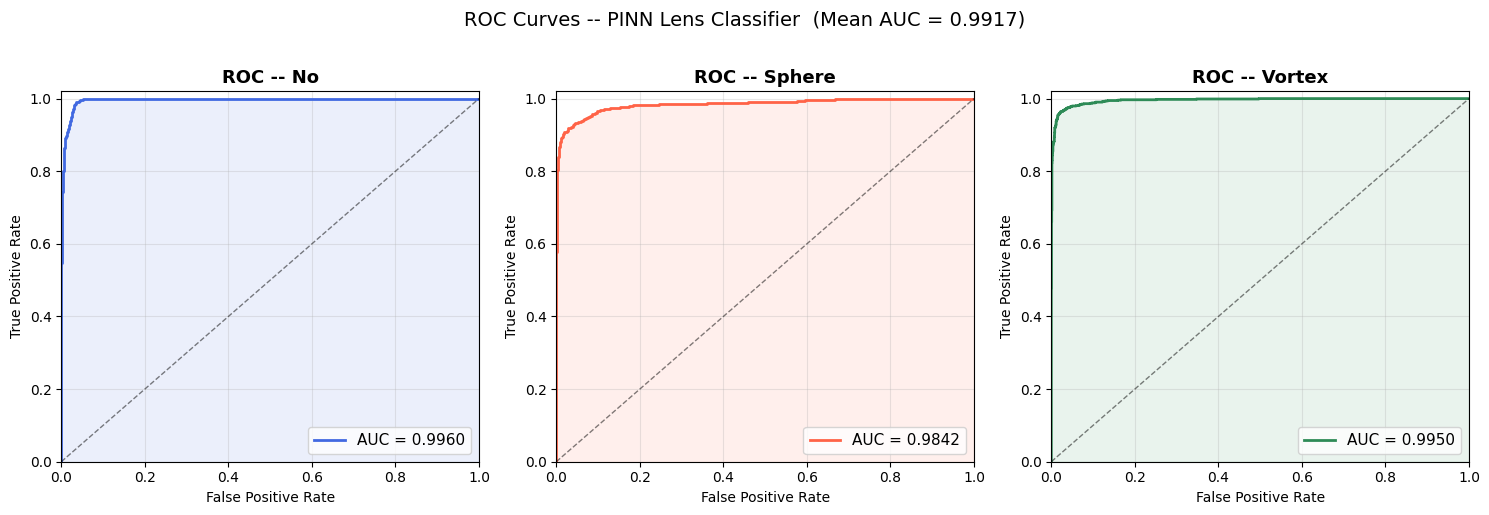

Saved: roc_curves_test.png


In [34]:
CLASS_LABELS = ['No', 'Sphere', 'Vortex']
y_bin = label_binarize(test_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['royalblue', 'tomato', 'seagreen']

for i, (ax, color, name) in enumerate(zip(axes, colors, CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], test_probs[:, i])

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_i:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'ROC -- {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle(f'ROC Curves -- PINN Lens Classifier  (Mean AUC = {test_auc:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_test.png")

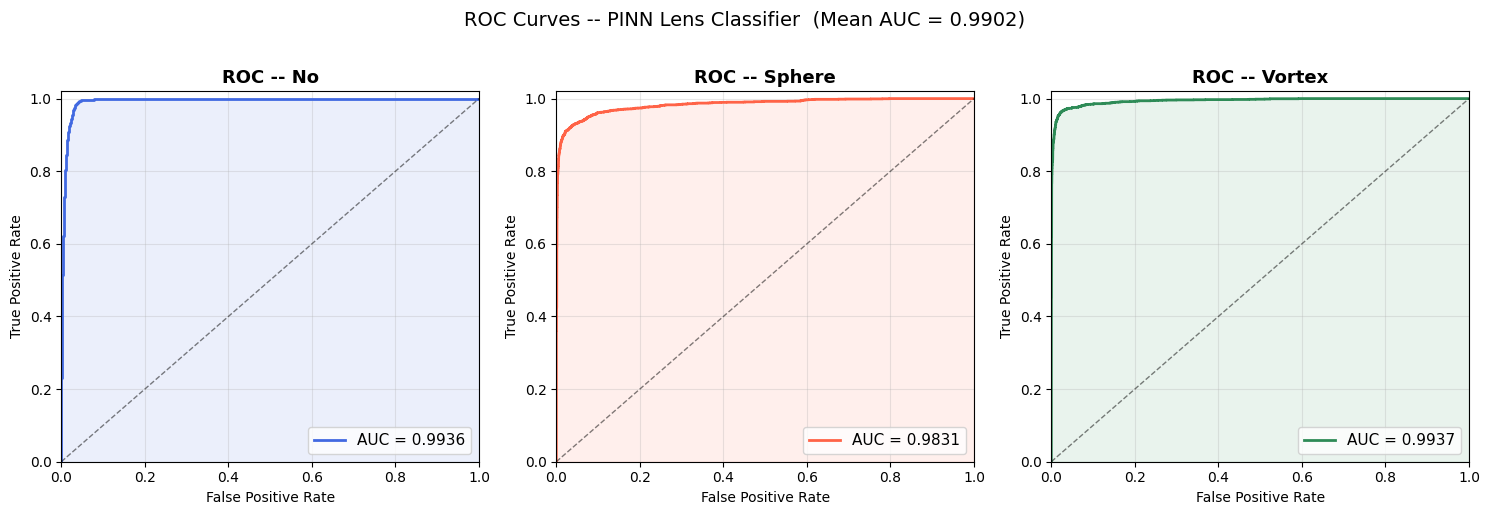

Saved: roc_curves_val.png


In [35]:
CLASS_LABELS = ['No', 'Sphere', 'Vortex']
y_bin = label_binarize(val_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['royalblue', 'tomato', 'seagreen']

for i, (ax, color, name) in enumerate(zip(axes, colors, CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], val_probs[:, i])
    auc_i = roc_auc_score(y_bin[:, i], val_probs[:, i])

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_i:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'ROC -- {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle(f'ROC Curves -- PINN Lens Classifier  (Mean AUC = {val_auc:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_val.png")

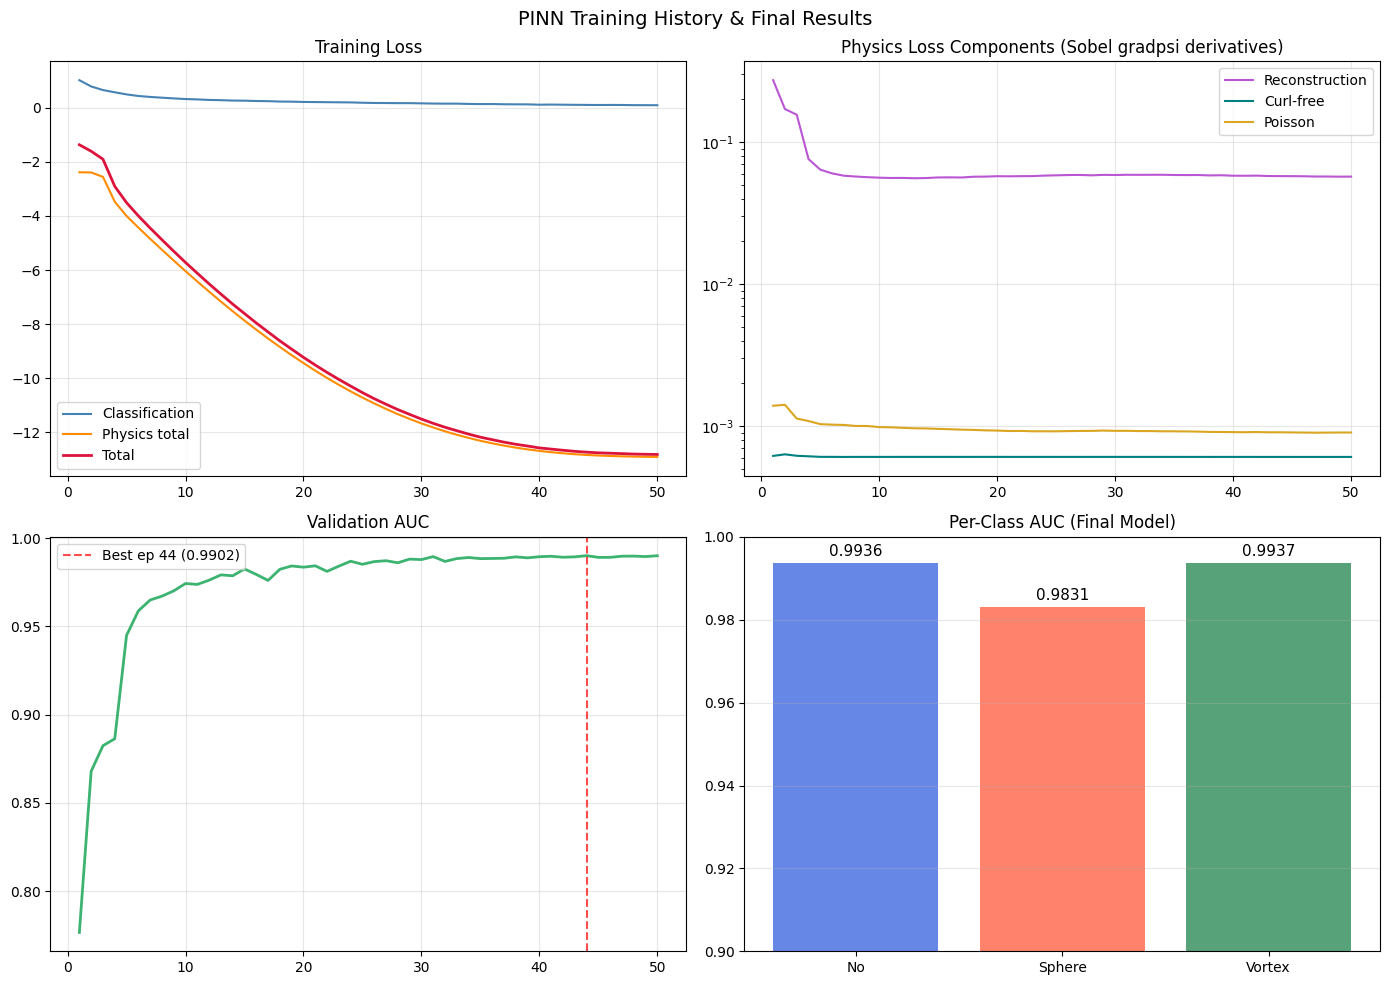

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ep = range(1, NUM_EPOCHS + 1)

axes[0,0].plot(ep, history['cls_loss'],   label='Classification', color='steelblue')
axes[0,0].plot(ep, history['phys_loss'],  label='Physics total',  color='darkorange')
axes[0,0].plot(ep, history['train_loss'], label='Total',          color='crimson', lw=2)
axes[0,0].set_title('Training Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history['recon_loss'],   label='Reconstruction', color='mediumorchid')
axes[0,1].plot(ep, history['curl_loss'],    label='Curl-free',      color='teal')
axes[0,1].plot(ep, history['poisson_loss'], label='Poisson',        color='goldenrod')
axes[0,1].set_title('Physics Loss Components (Sobel gradpsi derivatives)')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,1].set_yscale('log')

axes[1,0].plot(ep, history['val_auc'], color='mediumseagreen', lw=2)
axes[1,0].axvline(best_epoch, color='red', ls='--', alpha=0.7,
                  label=f'Best ep {best_epoch} ({best_auc:.4f})')
axes[1,0].set_title('Validation AUC'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

for i, (name, color) in enumerate(zip(CLASS_LABELS, colors)):
    auc_i = roc_auc_score(y_bin[:, i], val_probs[:, i])
    axes[1,1].bar(name, auc_i, color=color, alpha=0.8)
axes[1,1].set_ylim([0.9, 1.0])
axes[1,1].set_title('Per-Class AUC (Final Model)')
axes[1,1].grid(axis='y', alpha=0.3)
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{bar.get_height():.4f}',
                   ha='center', va='bottom', fontsize=11)

plt.suptitle('PINN Training History & Final Results', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

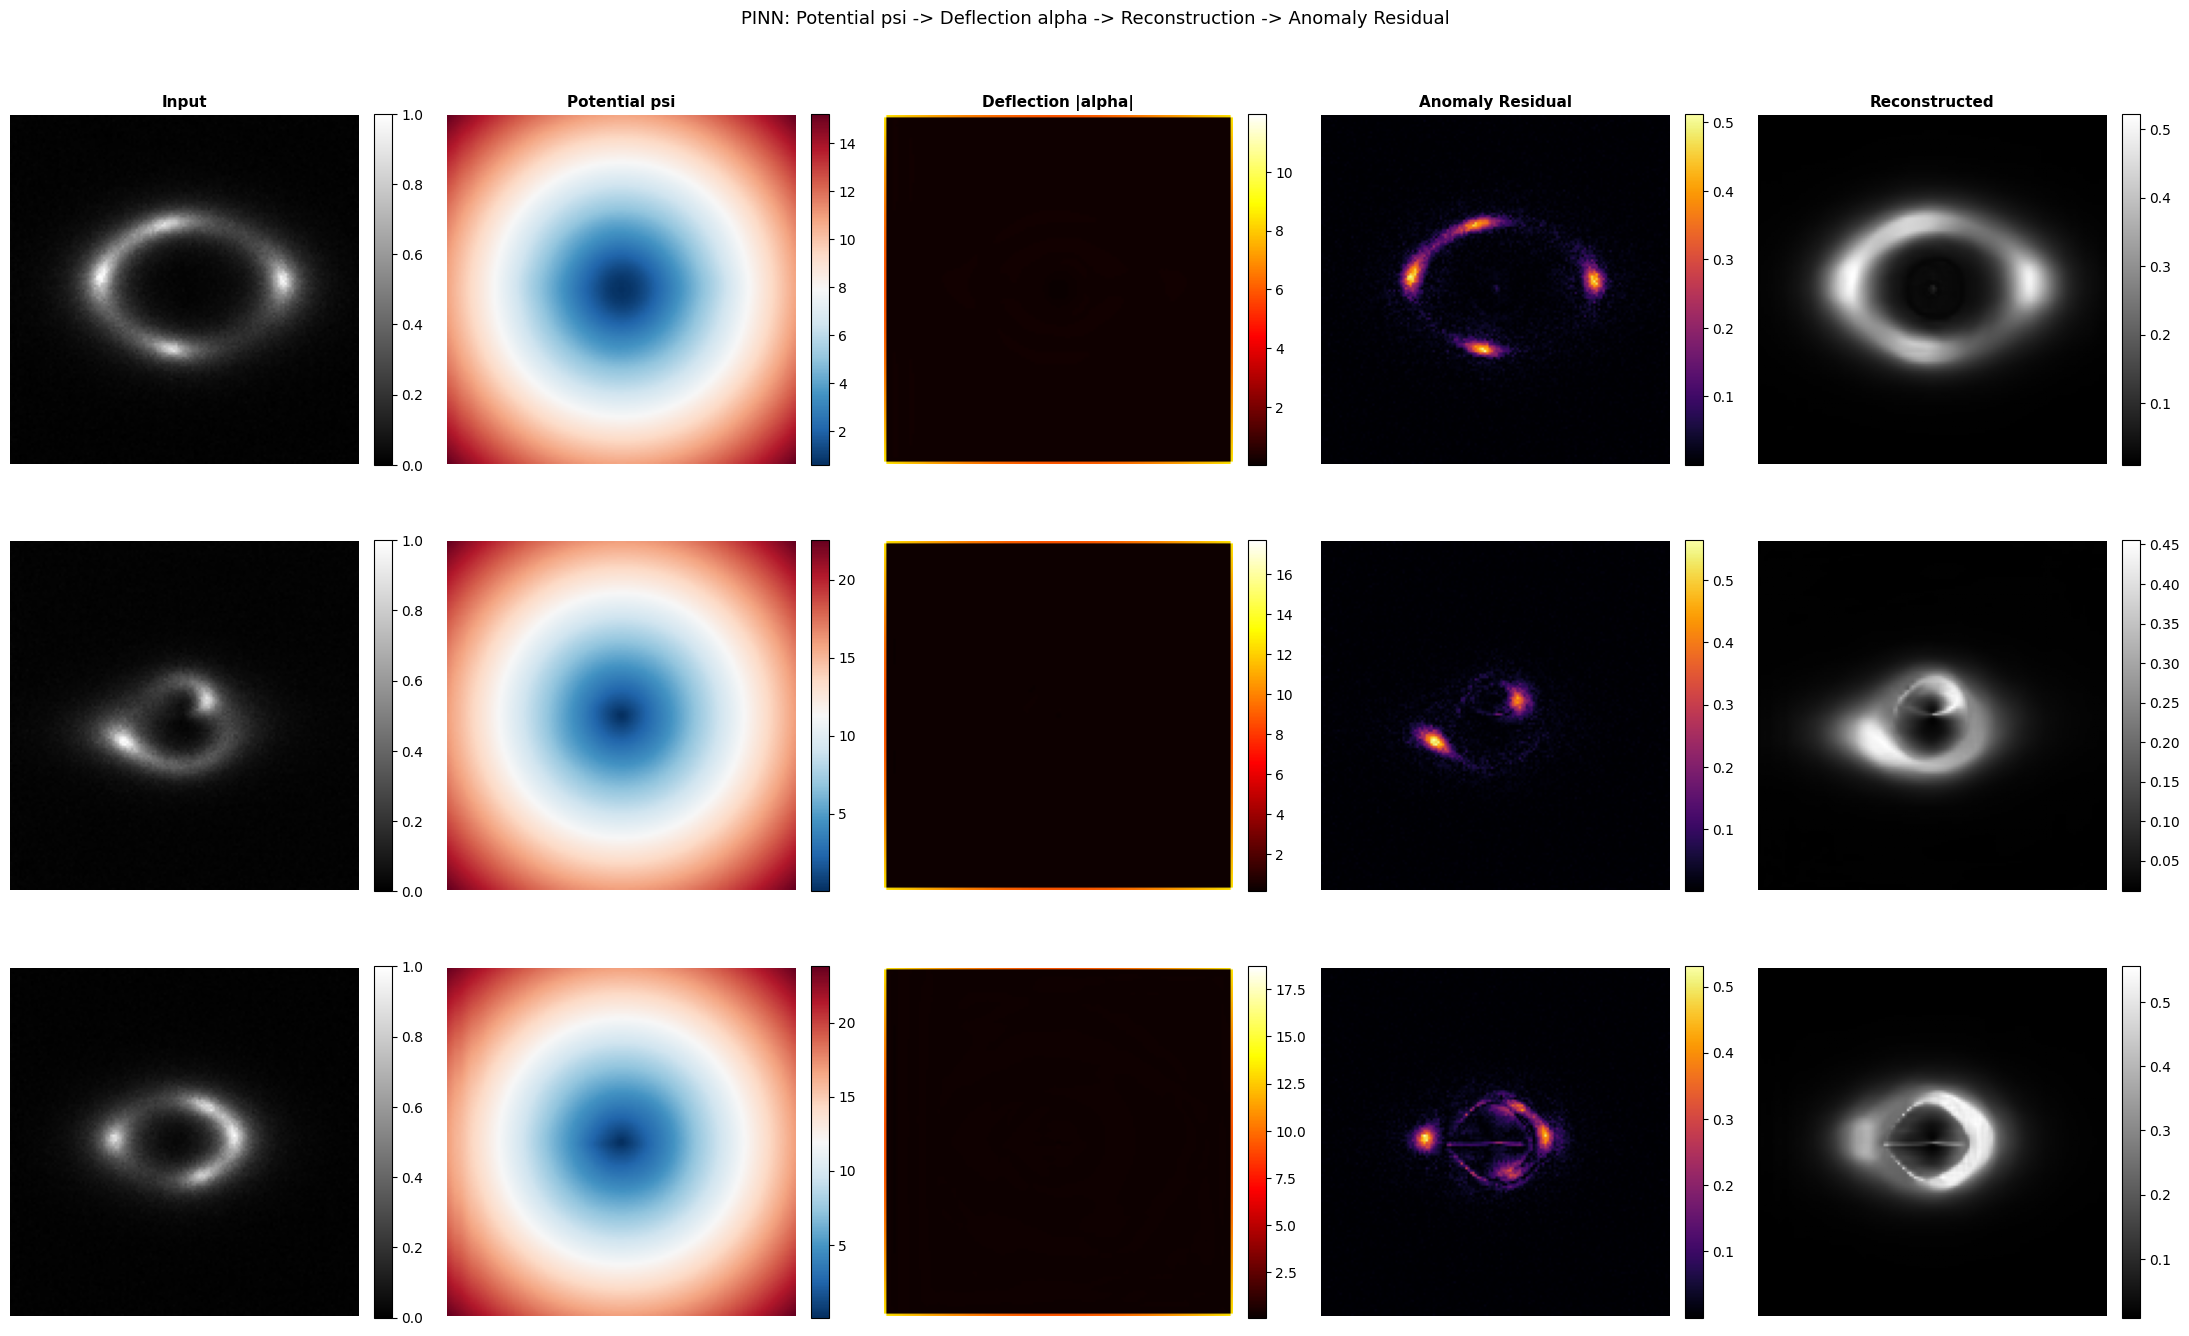

In [37]:
@torch.no_grad()
def visualize_all(model, dataset, n_samples=3):
    model.eval()
    indices = random.sample(range(len(dataset)), n_samples)
    class_labels = ['No Substructure', 'Subhalo', 'Vortex']

    col_titles = ['Input', 'Potential psi', 'Deflection |alpha|',
                  'Anomaly Residual', 'Reconstructed']
    cmaps      = ['gray', 'RdBu_r', 'hot', 'inferno', 'gray']

    fig, axes = plt.subplots(n_samples, 5, figsize=(22, 4.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img, label = dataset[idx]
        x = img.unsqueeze(0).to(device)

        logits, psi, psi_resid, alpha, theta_E, i_recon, i_src, residual, kappa, kappa_peak, curl_mag, i_delensed = model(x)
        pred = logits.argmax(dim=1).item()

        alpha_np    = alpha[0].cpu().numpy()
        magnitude   = np.sqrt(alpha_np[0]**2 + alpha_np[1]**2)
        psi_np      = psi[0, 0].cpu().numpy()
        residual_np = residual[0, 0].cpu().numpy()
        recon_np    = i_recon[0, 0].cpu().numpy()
        img_np      = img[0].numpy()

        imgs_to_show = [img_np, psi_np, magnitude, residual_np, recon_np]

        gt_correct = 'v' if pred == label else 'x'
        axes[row, 0].set_ylabel(
            f'{gt_correct} GT: {class_labels[label]}\n   Pred: {class_labels[pred]}',
            fontsize=9)

        for col, (arr, cmap) in enumerate(zip(imgs_to_show, cmaps)):
            im = axes[row, col].imshow(arr, cmap=cmap)
            plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
            axes[row, col].axis('off')

    plt.suptitle('PINN: Potential psi -> Deflection alpha -> Reconstruction -> Anomaly Residual',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('pinn_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_all(model, val_dataset, n_samples=3)

In [38]:
print("=" * 64)
print("  PINN Gravitational Lensing Classifier -- Final Summary")
print("=" * 64)
print(f"  Backbone            : ResNet18 (pretrained, 1-ch)")
print(f"  Input size          : {IMG_SIZE}x{IMG_SIZE}")
print()
print("  Architecture -- Physics Embedded by Design:")
print("    SIS prior:   psi_SIS = theta_E * r   (learnable Einstein radius)")
print("    Residual:    psi_total = psi_SIS + psi_resid  (CNN predicts deviations)")
print("    Deflection:  alpha = gradpsi_total       (curl-free BY CONSTRUCTION)")
print("    Warp:        beta = theta - alpha(theta)       (lensing equation as forward pass)")
print("    Poisson:     Deltapsi_resid = 2kappa_sub  (subhalo convergence constraint)")
print()
print("  Novel Contributions:")
print("  A. Anomaly Residual Branch  |I - I_recon| -> substructure signal")
print("  B. Potential-Derived alpha      psi_SIS + psi_resid -> alpha = gradpsi structurally")
print("  C. Polar Coordinate Branch  exploits circular lensing symmetry")
print()
print("  Physics Losses (curriculum-ramped over 5 warmup epochs):")
print("    ||Deltapsi_resid||^2  (Poisson / kappa_sub)  +  ||gradxalpha||^2  +  MSE recon")
print(f"  Best epoch          : {best_epoch}")
print(f"  Best Val AUC (OvR)  : {best_auc:.4f}")
print("=" * 64)


  PINN Gravitational Lensing Classifier -- Final Summary
  Backbone            : ResNet18 (pretrained, 1-ch)
  Input size          : 150x150

  Architecture -- Physics Embedded by Design:
    SIS prior:   psi_SIS = theta_E * r   (learnable Einstein radius)
    Residual:    psi_total = psi_SIS + psi_resid  (CNN predicts deviations)
    Deflection:  alpha = gradpsi_total       (curl-free BY CONSTRUCTION)
    Warp:        beta = theta - alpha(theta)       (lensing equation as forward pass)
    Poisson:     Deltapsi_resid = 2kappa_sub  (subhalo convergence constraint)

  Novel Contributions:
  A. Anomaly Residual Branch  |I - I_recon| -> substructure signal
  B. Potential-Derived alpha      psi_SIS + psi_resid -> alpha = gradpsi structurally
  C. Polar Coordinate Branch  exploits circular lensing symmetry

  Physics Losses (curriculum-ramped over 5 warmup epochs):
    ||Deltapsi_resid||^2  (Poisson / kappa_sub)  +  ||gradxalpha||^2  +  MSE recon
  Best epoch          : 44
  Best Val AUC (O